## 1. uzdevums. Sagatavo datus regresijai

## 1.1. Ielādē datu kopu

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ielādē 1. nedēļā sagatavoto tīro datu kopu
df = pd.read_csv('../week1/shoppers_clean.csv')
print(f"Datu kopa: {df.shape[0]} rindas, {df.shape[1]} kolonnas")


Datu kopa: 12330 rindas, 28 kolonnas


## 1.2. Izvēlies target un features

PageValues statistika:
count    1.233000e+04
mean     9.220344e-18
std      1.000041e+00
min     -3.171778e-01
25%     -3.171778e-01
50%     -3.171778e-01
75%     -3.171778e-01
max      1.916634e+01
Name: PageValues, dtype: float64


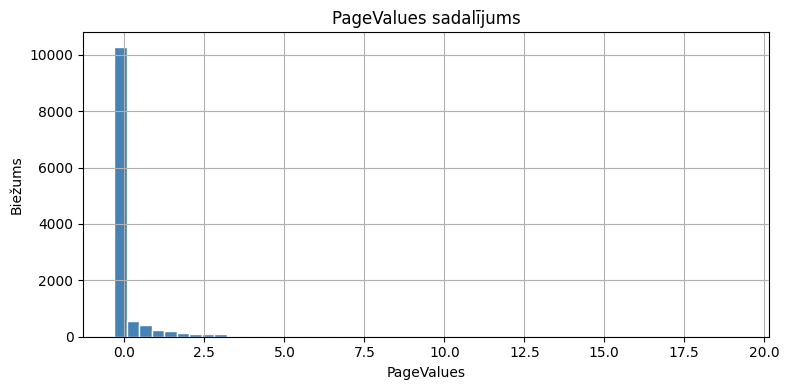

In [2]:
# Apskatām target mainīgo
print("PageValues statistika:")
print(df['PageValues'].describe())

plt.figure(figsize=(8, 4))
df['PageValues'].hist(bins=50, color='steelblue', edgecolor='white')
plt.title('PageValues sadalījums')
plt.xlabel('PageValues')
plt.ylabel('Biežums')
plt.tight_layout()
plt.show()


## 1.3. Sagatavo X un y

In [3]:
# Target
y = df['PageValues']

# Features — visas kolonnas, izņemot PageValues un Revenue
X = df.drop(['PageValues', 'Revenue'], axis=1)

print(f"Features skaits: {X.shape[1]}")
print(f"Target: PageValues")


Features skaits: 26
Target: PageValues


Revenue ir tieša atbilde uz jautājumu nopirka/nenopirka un ir ļoti saistīts ar PageValue, ja atbilde ir nopirka tad PageValue noteikti būs augsts un attiecīgi atstājot šo lauku modulis nevis mācīsies prognozēt, bet ies vieglāko ceļu un nolasīs datus no Revenue. Data leake ir kad modulis treniņa laikā redz datus, kuri reālā dzīvē tam nav pieejami, bīstami, jo modulis nevis mācīsies prognozēt, bet nolasīs gatavās atbildes un reālajā dzīvē no tā nebūs jēgas.

## 1.4. Treniņa/testa sadalījums

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Treniņa kopa: {X_train.shape[0]} rindas")
print(f"Testa kopa: {X_test.shape[0]} rindas")


Treniņa kopa: 9864 rindas
Testa kopa: 2466 rindas


## 2. uzdevums. Uztrenē lineārās regresijas modeli

## 2.1. Modeļa trenēšana

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Izveido un uztrenē modeli
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Prognozes
y_pred = lr_model.predict(X_test)

# Metrikas
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=== Lineāra regresija: rezultāti ===")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")


=== Lineāra regresija: rezultāti ===
MSE:  0.9892
RMSE: 0.9946
MAE:  0.5009
R²:   0.0456


## 2.2. Interpretē metrikas (Markdown šūna)

MAE - vidējā kļūda. Šajā rādītājā modelis saskaita visas kļūdas un aprēķina no tām vidējo, šo datu gadījumā kļūda ir 0,5 punkti. RMSE ir līdzīgs MAE, bet pirms vidējās kļūdas aprēķina tās tiek kāpinātas kvadrātā, šādā veidā ''kāpinot'' ļoti lielas kļūdas un iekļaujot tās vidējā aprēķinā attiecīgi šis rādītājs būs precīzāks par MAE. R2 - cik procentus no datu variācijām modelis izskaidro, jo tuvāk 1, jo vairāk modelis saprot, jo rādītājs zemāks, attiecīgi jo lielāka ir nejaušība. Šis modelis nav labs, MAE 0,5 - kontekstā ar Page Value statistiku, kur pārsvarā visi klienti ir -0,137, atskaitot nedaudzus, kur kļūda uzlec līdz 1,9 sanāk, ka kļūda nav vienmērīga un attiecīgi dati nav pārāk uzticami, ko papildina arī  RMSE: 0,9946 - tātad plusā daudzas lielas kļūdas un rādītājs vispār ir tuvu 1, kas ir 2x lielāks par MAE. R2 = 0,0456 - TĀTAD PRAKTISKI VISI IR NEJAUŠI MINĒJUMI.

## 3. uzdevums. Vizualizē prognozes

## 3.1. Faktiskās vs. prognozētās vērtības

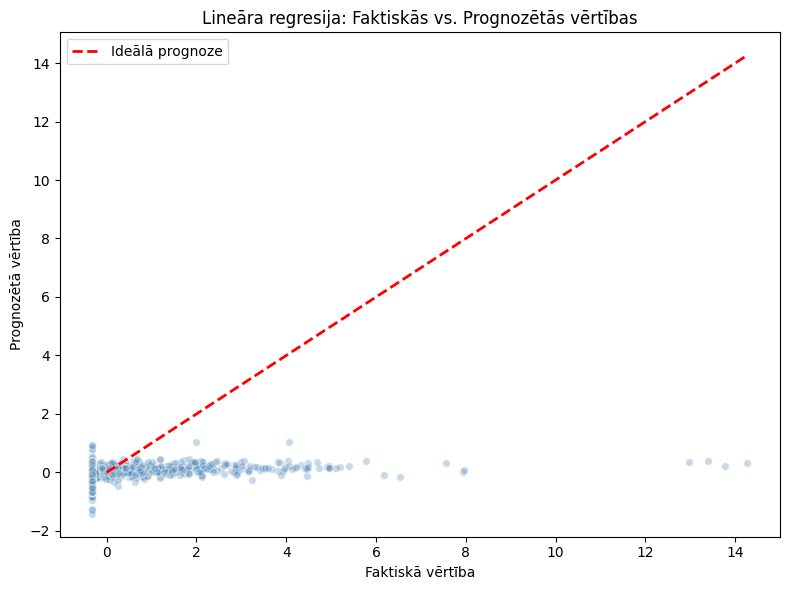

In [6]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue', edgecolors='white', s=30)

# Ideālā līnija (ja prognoze = realitāte)
max_val = max(y_test.max(), y_pred.max())
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Ideālā prognoze')

plt.xlabel('Faktiskā vērtība')
plt.ylabel('Prognozētā vērtība')
plt.title('Lineāra regresija: Faktiskās vs. Prognozētās vērtības')
plt.legend()
plt.tight_layout()
plt.show()


## 3.2. Atlikumu (residuals) analīze

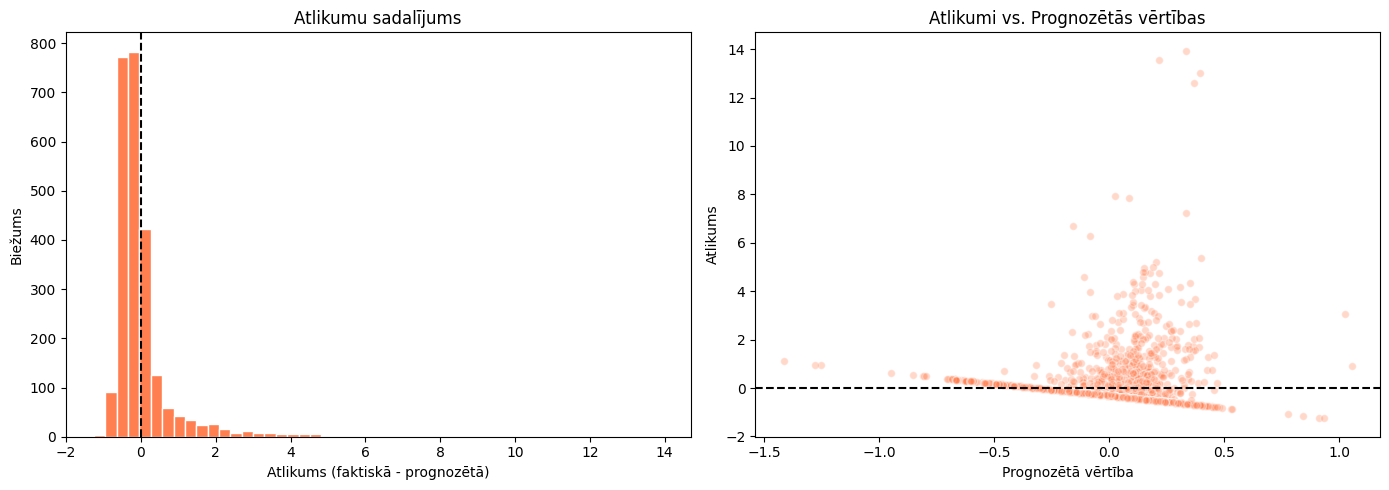

In [7]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Atlikumu sadalījums
axes[0].hist(residuals, bins=50, color='coral', edgecolor='white')
axes[0].set_title('Atlikumu sadalījums')
axes[0].set_xlabel('Atlikums (faktiskā - prognozētā)')
axes[0].set_ylabel('Biežums')
axes[0].axvline(x=0, color='black', linestyle='--')

# Atlikumi vs. prognozētās vērtības
axes[1].scatter(y_pred, residuals, alpha=0.3, color='coral', edgecolors='white', s=30)
axes[1].axhline(y=0, color='black', linestyle='--')
axes[1].set_title('Atlikumi vs. Prognozētās vērtības')
axes[1].set_xlabel('Prognozētā vērtība')
axes[1].set_ylabel('Atlikums')

plt.tight_layout()
plt.show()


## 3.3. Interpretē vizualizācijas (Markdown šūna)

Punkti Scatter grafikā ir tālu no sarkanās līnijas plus tie pat neseko līnijas virzienam un koncentrējās grafika apakšmalā mākonīti, kas vizuāli apliecina R2 rādījumu, ka modelis prognozēt nemāk. Residuals analīzē atlikumiem būtu jābūt vienmērīgi sadalītiem ap nulli un prognozētājām vērtībām punktiem būtu jābūt vienmērīgi izkaisītiem ap horizontālo vērtību. Biass norāda, ka modelis sistemātiski kļūdās vienā virzienā, manā gadījumā vairākums ir pozitīvi attiecīgi modelis visu laiku prognozē ''par maz''. Plus Scatter ir piltuves forma un tas jau norāda uz to ka datos ir nelineāras sakritības, kuras lineārais modelis nespēj uztvert. Vizualizācija tikai apstiprina to, ka modelis nav labs.

## 4. uzdevums. Izmēģini polinomiālo regresiju

## 4.1. PolynomialFeatures ar degree=2

In [8]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

# Izveido pipeline: PolynomialFeatures → LinearRegression
poly_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('lr', LinearRegression())
])

# Trenēšana
poly_pipeline.fit(X_train, y_train)

# Prognozes
y_pred_poly = poly_pipeline.predict(X_test)

# Metrikas
mae_poly = mean_absolute_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
r2_poly = r2_score(y_test, y_pred_poly)

print("=== Polinomiālā regresija (degree=2): rezultāti ===")
print(f"MAE:  {mae_poly:.4f}")
print(f"RMSE: {rmse_poly:.4f}")
print(f"R²:   {r2_poly:.4f}")


=== Polinomiālā regresija (degree=2): rezultāti ===
MAE:  0.4888
RMSE: 0.9993
R²:   0.0364


## 4.2. Salīdzinājuma tabula

In [9]:
comparison = pd.DataFrame({
    'Modelis': ['Lineārā regresija', 'Polinomiālā regresija'],
    'MAE': [mae, mae_poly],
    'RMSE': [rmse, rmse_poly],
    'R²': [r2, r2_poly]
})

print(comparison.to_string(index=False))

              Modelis      MAE     RMSE       R²
    Lineārā regresija 0.500925 0.994572 0.045556
Polinomiālā regresija 0.488841 0.999347 0.036370


## 4.3. Pārbaudīt overfitting (train vs. test)

In [10]:
# R² uz treniņa un testa datiem
lr_train_r2 = lr_model.score(X_train, y_train)
lr_test_r2 = lr_model.score(X_test, y_test)
poly_train_r2 = poly_pipeline.score(X_train, y_train)
poly_test_r2 = poly_pipeline.score(X_test, y_test)

print("=== Overfitting pārbaude ===")
print(f"Lineārā regresija:      Train R² = {lr_train_r2:.4f}, Test R² = {lr_test_r2:.4f}, Starpība = {abs(lr_train_r2 - lr_test_r2):.4f}")
print(f"Polinomiālā regresija:  Train R² = {poly_train_r2:.4f}, Test R² = {poly_test_r2:.4f}, Starpība = {abs(poly_train_r2 - poly_test_r2):.4f}")

# Brīdinājums
if abs(lr_train_r2 - lr_test_r2) > 0.10:
    print("\n⚠️ Lineārajai regresijai ir overfitting pazīmes!")
if abs(poly_train_r2 - poly_test_r2) > 0.10:
    print("\n⚠️ Polinomiālajai regresijai ir overfitting pazīmes!")
if abs(lr_train_r2 - lr_test_r2) <= 0.10 and abs(poly_train_r2 - poly_test_r2) <= 0.10:
    print("\n✓ Nav overfitting pazīmju — abi modeļi ir stabili.")

=== Overfitting pārbaude ===
Lineārā regresija:      Train R² = 0.0568, Test R² = 0.0456, Starpība = 0.0112
Polinomiālā regresija:  Train R² = 0.1334, Test R² = 0.0364, Starpība = 0.0971

✓ Nav overfitting pazīmju — abi modeļi ir stabili.


## 4.4. Vizuāls salīdzinājums

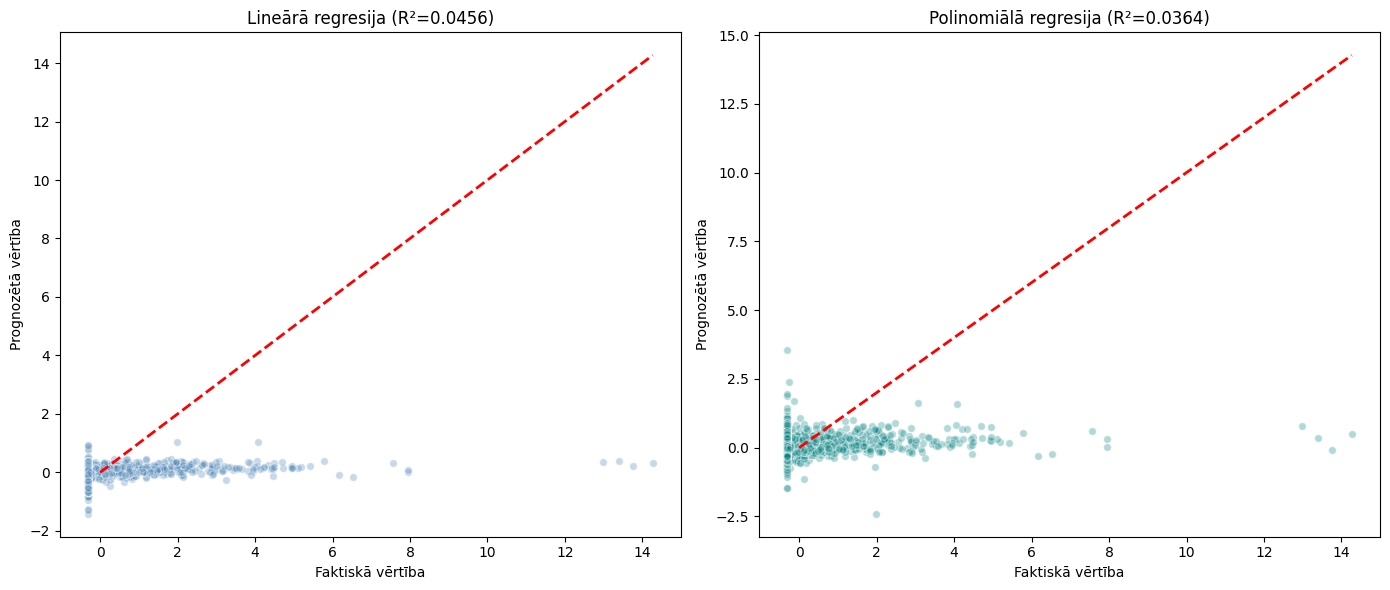

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Lineārā regresija
axes[0].scatter(y_test, y_pred, alpha=0.3, color='steelblue', edgecolors='white', s=30)
max_val = max(y_test.max(), y_pred.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=2)
axes[0].set_xlabel('Faktiskā vērtība')
axes[0].set_ylabel('Prognozētā vērtība')
axes[0].set_title(f'Lineārā regresija (R²={r2:.4f})')

# Polinomiālā regresija
axes[1].scatter(y_test, y_pred_poly, alpha=0.3, color='teal', edgecolors='white', s=30)
max_val_poly = max(y_test.max(), y_pred_poly.max())
axes[1].plot([0, max_val_poly], [0, max_val_poly], 'r--', linewidth=2)
axes[1].set_xlabel('Faktiskā vērtība')
axes[1].set_ylabel('Prognozētā vērtība')
axes[1].set_title(f'Polinomiālā regresija (R²={r2_poly:.4f})')

plt.tight_layout()
plt.show()

## 4.5. Secinājumi (Markdown šūna)

Neskatoties uz to, ka abi modeļi ir slikti nedaudz labāk prognozē Lineārais modelis. Viņam visi rādītāji ir par pāris punktiem augstāki. Polinominālais modelis R2 nevis uzlaboja bet vēl vairāk pasliktināja. Overfitting pazīmju nav. Šie modeļi biznesa videi ir nederīgi, domāju ka Page Values nav īstā pazīme uz kā pamata veidot prognozi.